<a href="https://colab.research.google.com/github/hollymunck-glitch/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 18: Exploring APIs with yfinance

In this assignment, you will:
- Choose an industry you're interested in (such as tech, airlines, or retail)
- Use the `yfinance` Python package as an API to collect historical stock price data
- Clean and prepare the data for analysis
- Explore trends, volatility, and relationships between companies
- Summarize your findings and recommendation in a business memo

## Why This Matters

APIs (Application Programming Interfaces) allow businesses to pull live, real-world data from external sources directly into their analytics tools. Financial analysts, investment firms, and business leaders use APIs like `yfinance` to monitor company performance, assess market trends, and build models based on dynamic data.

This assignment helps you gain hands-on experience with one of the most common API workflows in business analytics: fetching, cleaning, analyzing, and interpreting financial data to support better decision-making.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_14_api.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Step 1: Choose an Industry and Find Company Ticker Symbols

Visit the following website to explore U.S. stock sectors and industries:  
https://www.tradingview.com/markets/stocks-usa/sectorandindustry-sector/

Choose one industry you are interested in (for example: Airlines, Technology, Fast Food, Retail, Energy, etc.).  
Write the names and ticker symbols of 4 public companies in that industry.

**Example:**
- Industry: Technology  
- Tickers: AAPL, MSFT


In [2]:
Industry = "Airlines"
tickers = ['DAL', 'AAL', 'UAL', 'LUV']

## Step 2: Use yfinance to Collect Historical Stock Data

Follow the steps below to use the `yfinance` API to collect historical stock price data.

### Instructions

1. Make sure the `yfinance` package is installed by running the code cell below.
2. Import any additional Python libraries that you might need to explore or visualize the data.
3. Use the `yf.download()` function to pull **5 years of daily adjusted close prices** for the companies you selected in Step 1.
    - Choose a start date and an end date that span the past 5 years (e.g., `"2020-01-01"` to `"2025-12-31"`).
    - Only select the **'High'** column, which represents the daily high
4. Preview the first few rows of the dataset using `.head()` to confirm that the data has loaded correctly.



In [3]:
# Import necessary libraries
!pip install yfinance

import yfinance as yf
import pandas as pd

In [4]:
# Download adjusted close prices
df = yf.download(tickers, start="2020-01-01", end="2025-01-01")['High']

/tmp/ipython-input-379398263.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-01-01")['High']
[*********************100%***********************]  4 of 4 completed


In [6]:
df.head()

Ticker,AAL,DAL,LUV,UAL
Date,,,,
2020-01-02,29.192119,57.380411,51.076642,90.570000
2020-01-03,28.185840,56.153377,50.657751,88.160004
2020-01-06,27.388784,55.805561,50.788083,88.070000
2020-01-07,27.578085,56.105071,50.639139,88.160004
2020-01-08,27.986575,57.390066,50.881162,88.449997


## Step 3: Clean the Data

The data you pulled may contain missing values. Follow these steps:

1. Check the dataset for missing values using `.isnull().sum()`.
2. Fill any missing values using a forward fill method.
3. Recheck for missing values to confirm they have been handled.



In [7]:
# Add code here 🔧
# 1. Check for missing values
df.isnull().sum()

# 2. Fill missing values using forward fill
df_filled = df.ffill()

# 3. Recheck for missing values
df_filled.isnull().sum()


,0
Ticker,
AAL,0
DAL,0
LUV,0
UAL,0


## Step 4: Calculate Daily Returns

To better understand price movement, calculate the daily percentage change for each stock.

1. Use the `.pct_change()` method to calculate daily returns.
2. Drop any rows with missing values that may result from this calculation.
3. Preview the returns DataFrame to confirm it's correct.


In [9]:
# Add code here 🔧
# Use the cleaned dataframe from Step 3
returns = df_filled.pct_change()

# Drop rows with missing values (first row will be NaN)
returns = returns.dropna()

# Preview the daily returns
returns.head()


Ticker,AAL,DAL,LUV,UAL
Date,,,,
2020-01-03,-0.034471,-0.021384,-0.008201,-0.026609
2020-01-06,-0.028279,-0.006194,0.002573,-0.001021
2020-01-07,0.006912,0.005367,-0.002933,0.001022
2020-01-08,0.014812,0.022903,0.004779,0.003289
2020-01-09,0.004984,0.001178,0.002927,0.003053


## Step 5: Explore the Data Visually and Statistically

In this step, you will create visualizations and metrics to help understand stock behavior. Don’t interpret or explain anything here — just create the outputs so you can use them in your reflection later.

1. Create a line chart showing stock prices over the 5-year period.
2. Calculate the standard deviation of daily returns for each stock (volatility).
3. Create a correlation matrix of the daily returns between companies.




<Figure size 1200x600 with 0 Axes>

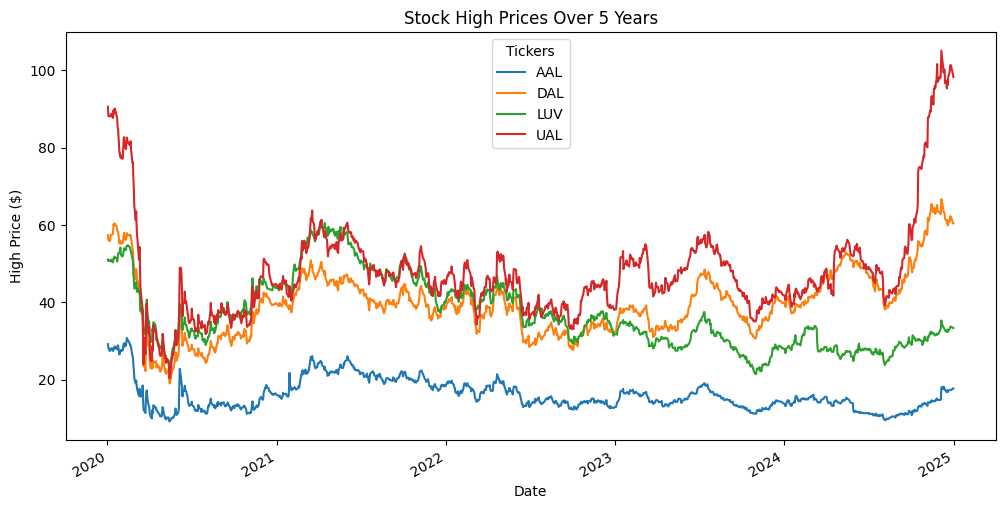

,0
Ticker,
AAL,0.039806
DAL,0.029321
LUV,0.024074
UAL,0.037255


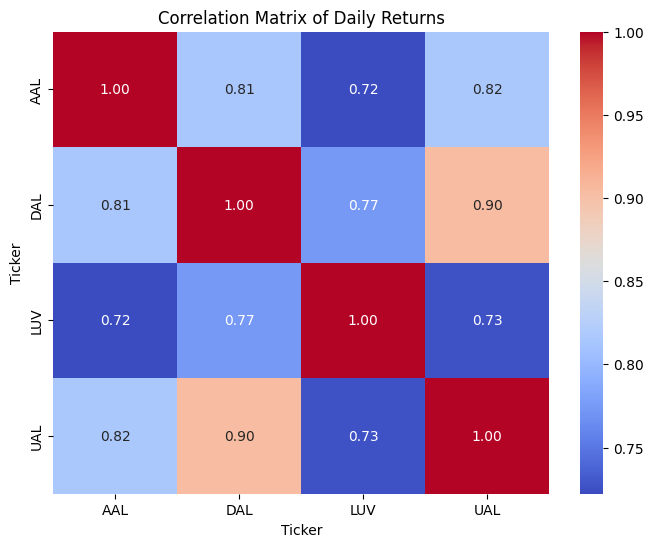

In [10]:
# Add code here 🔧
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Line chart of stock prices (High prices over 5 years)
plt.figure(figsize=(12,6))
df_filled.plot(figsize=(12,6))
plt.title("Stock High Prices Over 5 Years")
plt.xlabel("Date")
plt.ylabel("High Price ($)")
plt.legend(title="Tickers")
plt.show()

# 2. Standard deviation of daily returns (volatility)
volatility = returns.std()
display(volatility)

# 3. Correlation matrix of daily returns
corr_matrix = returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Daily Returns")
plt.show()


## Step 6: Write a Stakeholder Recommendation Memo

Now that you’ve completed your analysis, it’s time to turn your work into a clear, professional memo for a business audience.

### Scenario

You’ve been asked by a stakeholder (an investor, executive, or client) to evaluate whether it's a good time to invest in a particular industry. They’ve asked you to use recent stock performance data from several leading companies in that industry to help guide their decision.

### Your Task

Use the results from your code in Steps 2–5 to write a **multi-paragraph business memo** that:

1. **Introduces the industry you analyzed** and names the companies you included.
2. **Summarizes major trends** you observed in the stock prices over the last 5 years.
3. **Discusses key metrics**, such as volatility and correlations between companies.
4. **Presents your investment recommendation** — based on your evidence — and explains why you would or wouldn’t advise investing in this industry now.
5. **Suggests future analytics or data sources** that could strengthen or update your recommendation going forward.

This final section should show that you understand how real-world decisions evolve. Think about:
- What **additional data** might help (e.g., earnings reports, economic indicators, sentiment analysis)?
- What **types of models** could be applied (e.g., forecasting, classification, risk modeling)?
- How often should the analysis be updated?

### Format & Expectations

- Write **2–4 paragraphs** in business memo format (not bullet points).
- Use **specific, data-driven evidence** from your own analysis.
- Keep your writing professional and clear — imagine your reader is a client or executive, not a data analyst.
- Your memo should be written **entirely in your own words**. Do not copy from examples, online sources, or AI tools. Your writing should reflect your understanding and your interpretation of the results.
- You do not need to include charts in the memo — the code cells above already display them.



### Add memo here:

I analyzed the U.S. airline industry with 5 years of historical stock data from Delta (DAL), American Airlines (AAL), United Airlines (UAL), and Southwest (LUV). These four companies are major carriers with large domestic and international networks, offering a good view of the industry’s financial performance and investor sentiment. The dataset included daily high prices from 2020 through early 2025, allowing for a review of both long-term trends and short-term volatility.

Across the five-year window, airline stock prices showed clear periods of recovery and pullback, showing the industry's sensitivity to economic conditions, fuel costs, and travel demand. All four companies trended upward after the pandemic period, their growth was uneven, with price fluctuations occurring more frequently than in many other sectors. The volatility results support this because the standard deviation of daily returns was relatively high for all four carriers, indicating a riskier investment profile. The correlation matrix showed strong positive correlations across the companies, meaning industry-wide events tend to affect them similarly, decreasing diversification benefits when investing in multiple airlines at once.

Based on the volatility and the high degree of correlation, I would be cautious about recommending a large investment in the airline industry right now. The data shows that there is potential for gains during periods of strong travel demand, but the stocks also react sharply to disruptions such as fuel price changes, labor issues, or economic slowdowns. For a risk-tolerant investor, a small or short-term position may be reasonable, but for a more conservative profile, I would not recommend heavy exposure to this industry at the moment without further supporting data.

To strengthen my recommendation going forward, I would add datasets like quarterly earnings reports, fuel price trends, TSA passenger volumes, consumer sentiment, and macroeconomic indicators. Forecasting models, such as ARIMA or multivariate regression, could help predict future price movements based on these inputs. Because airlines operate in a volatile environment, this analysis should be refreshed at least quarterly to reflect rapidly changing conditions. Continuous monitoring would create more confident decision-making as new trends come.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_14_LastnameFirstname.ipynb"